# **1. Load Packages & data**

# Preprocessing and Exploratory Data Analysis

This notebook performs comprehensive data preprocessing and exploratory data analysis on the Southern Vietnam Weather dataset (2015-2025).

## Objectives

1. Load and inspect the raw weather data
2. Clean and prepare the data for analysis
3. Handle missing values and outliers
4. Convert temperature units from Fahrenheit to Celsius
5. Perform feature selection using SHAP values
6. Conduct exploratory data analysis to understand weather patterns
7. Export processed data for modeling

## Dataset Overview

The dataset contains daily weather measurements from 18 provinces in Southern Vietnam, spanning from 2015 to 2025. Key features include temperature, humidity, precipitation, wind, solar radiation, and other meteorological variables.

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import time
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:
# Load the data
df = pd.read_csv("../data/raw/Southern_Vietnam_Weather_2015-2025.csv")

# Overview data
print("DATA OVERVIEW\n")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(df.info())
print("\nHead/Tail preview:")
display(df.head(3))
display(df.tail(3))


DATA OVERVIEW

Number of rows: 70146
Number of columns: 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70146 entries, 0 to 70145
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              70146 non-null  object 
 1   datetime          70146 non-null  object 
 2   tempmax           70146 non-null  float64
 3   tempmin           70146 non-null  float64
 4   temp              70146 non-null  float64
 5   feelslikemax      70146 non-null  float64
 6   feelslikemin      70146 non-null  float64
 7   feelslike         70146 non-null  float64
 8   dew               70146 non-null  float64
 9   humidity          70146 non-null  float64
 10  precip            70146 non-null  float64
 11  precipprob        70146 non-null  int64  
 12  precipcover       70146 non-null  float64
 13  preciptype        54208 non-null  object 
 14  snow              70146 non-null  float64
 15  snowdepth         70146 non-

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,An Giang,2015-01-01,82.5,71.7,77.2,85.5,71.7,78.1,69.7,78.8,...,16.0,7,NaN,2015-01-01T06:15:43,2015-01-01T17:47:23,0.36,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"48907099999,48912599999,remote"
1,An Giang,2015-01-02,78.9,68.1,74.7,78.9,68.1,74.7,63.5,68.6,...,17.2,8,NaN,2015-01-02T06:16:07,2015-01-02T17:47:56,0.39,"Rain, Partially cloudy",Partly cloudy throughout the day with afternoo...,rain,"48907099999,48912599999,remote"
2,An Giang,2015-01-03,84.3,73.1,77.6,87.6,73.1,78.4,68.4,73.8,...,17.5,8,NaN,2015-01-03T06:16:30,2015-01-03T17:48:28,0.43,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,"48907099999,48912599999,remote"


,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
70143,Đồng Tháp,2025-08-30,85.9,75.1,78.6,101.6,75.1,80.7,77.8,97.5,...,16.0,6,30.0,2025-08-30T05:48:03,2025-08-30T18:08:11,0.22,"Rain, Partially cloudy",Partly cloudy throughout the day with rain in ...,rain,VVCT
70144,Đồng Tháp,2025-08-31,85.9,76.9,79.0,104.4,76.9,82.6,78.3,97.7,...,17.5,8,30.0,2025-08-31T05:48:01,2025-08-31T18:07:36,0.25,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,VVCT
70145,Đồng Tháp,2025-09-01,84.1,75.1,78.0,98.0,75.1,79.7,77.7,99.3,...,13.3,6,30.0,2025-09-01T05:47:59,2025-09-01T18:07:00,0.29,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,VVCT


## Load Dataset

We begin by loading the raw weather data and examining its basic structure including dimensions, data types, and a preview of the first and last few rows.

# 2. Data Cleaning

Before conducting analysis, we need to ensure data quality by checking for:

- Missing values and patterns of missingness
- Duplicate records
- Proper date formatting for time series analysis
- Temperature unit conversion (Fahrenheit to Celsius)
- Elimination of irrelevant or redundant columns

## 2.1. Check Missing Values

MISSING VALUES PER COLUMN
            Missing Count  Missing %
severerisk          46188      65.85
preciptype          15938      22.72
visibility           7909      11.28


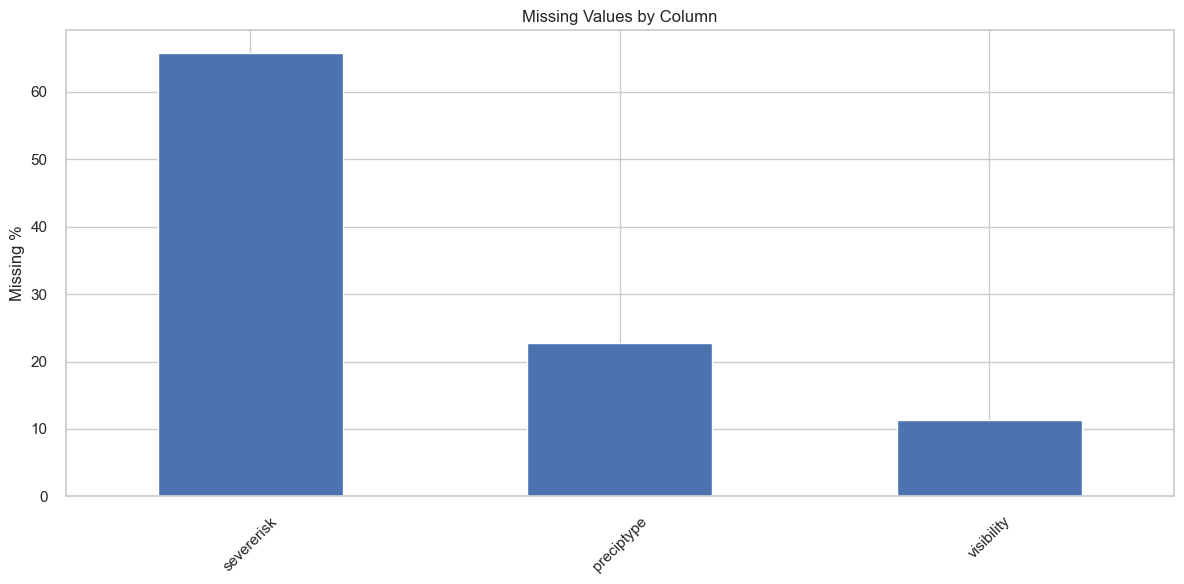

In [3]:
print("MISSING VALUES PER COLUMN")
missing = df.isnull().sum()
missing_percent = np.round(((missing[missing > 0]/df.shape[0])*100),2)
missing_df = pd.DataFrame({
    'Missing Count': missing[missing > 0],
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)
print(missing_df)

# Visualize missing value patterns
plt.figure(figsize=(12, 6))
missing_df['Missing %'].plot(kind='bar')
plt.title('Missing Values by Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/1_Preprocessing/missing_values_analysis.png', bbox_inches='tight')
plt.show()

We first identify which columns have missing values and calculate the percentage of missingness. This helps us decide on appropriate imputation strategies.

## 2.2. Check Duplicate Rows

In [4]:
# Checks for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# remove duplicates if  exists
if duplicates > 0:
    df.drop_duplicates(inplace=True)

Number of duplicate rows: 0


We check for duplicate rows to ensure data integrity. Duplicates can skew analysis and lead to incorrect conclusions.

## 2.3. Proper Date Formatting

In [5]:
# Convert time column to datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

# Sort for time series consistency
df = df.sort_values(['name', 'datetime']).reset_index(drop=True)

Convert the datetime column to proper datetime format for time series operations. We also sort the data by location and date to ensure temporal consistency.

## 2.4. Temperature Unit Conversion

Convert all temperature measurements from Fahrenheit to Celsius for consistency and easier interpretation in the Vietnamese context. The conversion formula is: C = (F - 32) × 5/9

In [6]:
# °F -> °C
def f2c(x):
    return round(((x - 32) * 5/9), 2)

temp_cols_f = ["tempmax","tempmin","temp","feelslikemax","feelslikemin","feelslike"]

# create new columns (°C)
for col in temp_cols_f:
    df[col + "_C"] = df[col].apply(f2c)

# Delete °F columns
df = df.drop(columns=temp_cols_f)

# Check
print(df.filter(like="_C").head())

   tempmax_C  tempmin_C  temp_C  feelslikemax_C  feelslikemin_C  feelslike_C
0      28.06      22.06   25.11           29.72           22.06        25.61
1      26.06      20.06   23.72           26.06           20.06        23.72
2      29.06      22.83   25.33           30.89           22.83        25.78
3      30.06      22.06   26.22           33.39           22.06        27.44
4      30.06      24.06   26.28           33.39           24.06        27.50


In [7]:
# Data validation after temperature conversion
print("TEMPERATURE CONVERSION VALIDATION\n")
print(f"Max temperature range: {df['tempmax_C'].min():.1f}°C to {df['tempmax_C'].max():.1f}°C")
print(f"Min temperature range: {df['tempmin_C'].min():.1f}°C to {df['tempmin_C'].max():.1f}°C")
print(f"Average temperature range: {df['temp_C'].min():.1f}°C to {df['temp_C'].max():.1f}°C")

# Check for any unreasonable values
unreasonable_max = ((df['tempmax_C'] < 0) | (df['tempmax_C'] > 60)).sum()
unreasonable_min = ((df['tempmin_C'] < -10) | (df['tempmin_C'] > 50)).sum()
print(f"Unreasonable max temp values: {unreasonable_max}")
print(f"Unreasonable min temp values: {unreasonable_min}")

TEMPERATURE CONVERSION VALIDATION

Max temperature range: 23.4°C to 42.8°C
Min temperature range: 2.0°C to 30.7°C
Average temperature range: 22.0°C to 35.4°C
Unreasonable max temp values: 0
Unreasonable min temp values: 0


After conversion, we validate that all temperature values fall within reasonable ranges for Southern Vietnam's tropical climate.

## 2.5. Feature Selection using SHAP Values

We use SHAP (SHapley Additive exPlanations) values to identify the most important features for predicting maximum temperature. This approach provides interpretable feature importance scores based on game theory principles.

In [8]:
print("Preparing Features and Target")
from xgboost import XGBRegressor

numeric_cols = df.select_dtypes(include=['number']).columns
feature_cols = [col for col in numeric_cols if col not in ['tempmax_C', 'name', 'datetime']]
X_shap = df[feature_cols] 
y_shap = df.groupby('name')['tempmax_C'].shift(-1)

mask = y_shap.notna()
X_shap = X_shap[mask]
y_shap = y_shap[mask]

print(f'Feature matrix shape: {X_shap.shape}')
print(f'Target matrix shape: {y_shap.shape}')

Preparing Features and Target
Feature matrix shape: (70128, 23)
Target matrix shape: (70128,)


First, we prepare the feature matrix and target variable. The target is the next day's maximum temperature, creating a forecasting setup.

In [9]:
import shap
# Shap-based feature selection
print("Training XGBoost for SHAP analysis")
xgb_for_shap = XGBRegressor(n_estimators=100, max_depth=3, random_state=42)
xgb_for_shap.fit(X_shap, y_shap)

print("Calculating SHAP values")
explainer = shap.TreeExplainer(xgb_for_shap)
shap_values = explainer.shap_values(X_shap)

# get feature importance
shap_importance = np.abs(shap_values).mean(0)
shap_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'shap_importance': shap_importance
}).sort_values('shap_importance', ascending=False)

print(f'Top 15 Features by SHAP Importance:')
shap_importance_df.iloc[:23]

Training XGBoost for SHAP analysis
Calculating SHAP values
Top 15 Features by SHAP Importance:


,feature,shap_importance
19,temp_C,0.943976
9,winddir,0.191706
1,humidity,0.187058
20,feelslikemax_C,0.182119
13,solarradiation,0.171682
10,sealevelpressure,0.113821
12,visibility,0.096108
18,tempmin_C,0.089384
11,cloudcover,0.089020
7,windgust,0.088649


Train a baseline XGBoost model and calculate SHAP values to understand feature importance. The SHAP values provide both magnitude and direction of each feature's impact.

In [10]:
# SHAP-based feature selection with threshold
print("SHAP FEATURE SELECTION WITH THRESHOLD")

threshold = 0.005  
selected_features_threshold = shap_importance_df[shap_importance_df['shap_importance'] >= threshold]['feature'].tolist()

print(f'Threshold-based selection (threshold={threshold}): {len(selected_features_threshold)} features')
print(f'\nThreshold-based features: {selected_features_threshold}')

# Use threshold-based selection (you can change this)
X_shap_selected = X_shap[selected_features_threshold]
df_shap = pd.concat([df[['name', 'datetime']], X_shap_selected, y_shap.rename('TARGET')], axis=1)

# Show feature importance for selected features
print(f'\nSelected features with SHAP importance:')
selected_importance = shap_importance_df[shap_importance_df['feature'].isin(selected_features_threshold)]
print(selected_importance)

df_shap

SHAP FEATURE SELECTION WITH THRESHOLD
Threshold-based selection (threshold=0.005): 19 features

Threshold-based features: ['temp_C', 'winddir', 'humidity', 'feelslikemax_C', 'solarradiation', 'sealevelpressure', 'visibility', 'tempmin_C', 'cloudcover', 'windgust', 'precipcover', 'dew', 'windspeed', 'moonphase', 'precip', 'solarenergy', 'severerisk', 'feelslike_C', 'feelslikemin_C']

Selected features with SHAP importance:
             feature  shap_importance
19            temp_C         0.943976
9            winddir         0.191706
1           humidity         0.187058
20    feelslikemax_C         0.182119
13    solarradiation         0.171682
10  sealevelpressure         0.113821
12        visibility         0.096108
18         tempmin_C         0.089384
11        cloudcover         0.089020
7           windgust         0.088649
4        precipcover         0.068107
0                dew         0.048255
8          windspeed         0.036989
17         moonphase         0.036500
2   

,name,datetime,temp_C,winddir,humidity,feelslikemax_C,solarradiation,sealevelpressure,visibility,tempmin_C,...,precipcover,dew,windspeed,moonphase,precip,solarenergy,severerisk,feelslike_C,feelslikemin_C,TARGET
0,An Giang,2015-01-01,25.11,348.8,78.8,29.72,186.3,1012.7,7.1,22.06,...,0.00,69.7,9.2,0.36,0.000,16.0,NaN,25.61,22.06,26.06
1,An Giang,2015-01-02,23.72,354.4,68.6,26.06,200.6,1013.4,7.0,20.06,...,4.17,63.5,9.2,0.39,0.008,17.2,NaN,23.72,20.06,29.06
2,An Giang,2015-01-03,25.33,350.1,73.8,30.89,201.7,1012.4,7.0,22.83,...,8.33,68.4,8.4,0.43,0.008,17.5,NaN,25.78,22.83,30.06
3,An Giang,2015-01-04,26.22,128.8,78.2,33.39,144.0,1010.6,6.9,22.06,...,12.50,71.5,6.7,0.46,0.012,12.6,NaN,27.44,22.06,30.06
4,An Giang,2015-01-05,26.28,150.2,85.0,33.39,155.2,1010.1,7.1,24.06,...,16.67,74.2,5.8,0.50,0.119,13.4,NaN,27.50,24.06,31.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70141,Đồng Tháp,2025-08-28,27.56,249.6,89.9,38.94,201.2,1008.5,6.6,24.94,...,20.83,78.1,12.8,0.16,0.403,17.4,30.0,31.22,24.94,29.94
70142,Đồng Tháp,2025-08-29,26.78,248.8,94.8,38.67,176.3,1007.8,6.1,24.94,...,66.67,78.5,13.9,0.19,0.435,15.2,30.0,29.72,24.94,29.94
70143,Đồng Tháp,2025-08-30,25.89,235.1,97.5,38.67,184.2,1007.3,6.1,23.94,...,29.17,77.8,13.9,0.22,0.213,16.0,30.0,27.06,23.94,29.94
70144,Đồng Tháp,2025-08-31,26.11,243.3,97.7,40.22,203.9,1007.0,5.8,24.94,...,37.50,78.3,13.9,0.25,0.221,17.5,30.0,28.11,24.94,28.94


Apply a threshold to select only features with meaningful SHAP importance. Features with very low importance (below 0.005) contribute minimally to predictions and can be excluded.

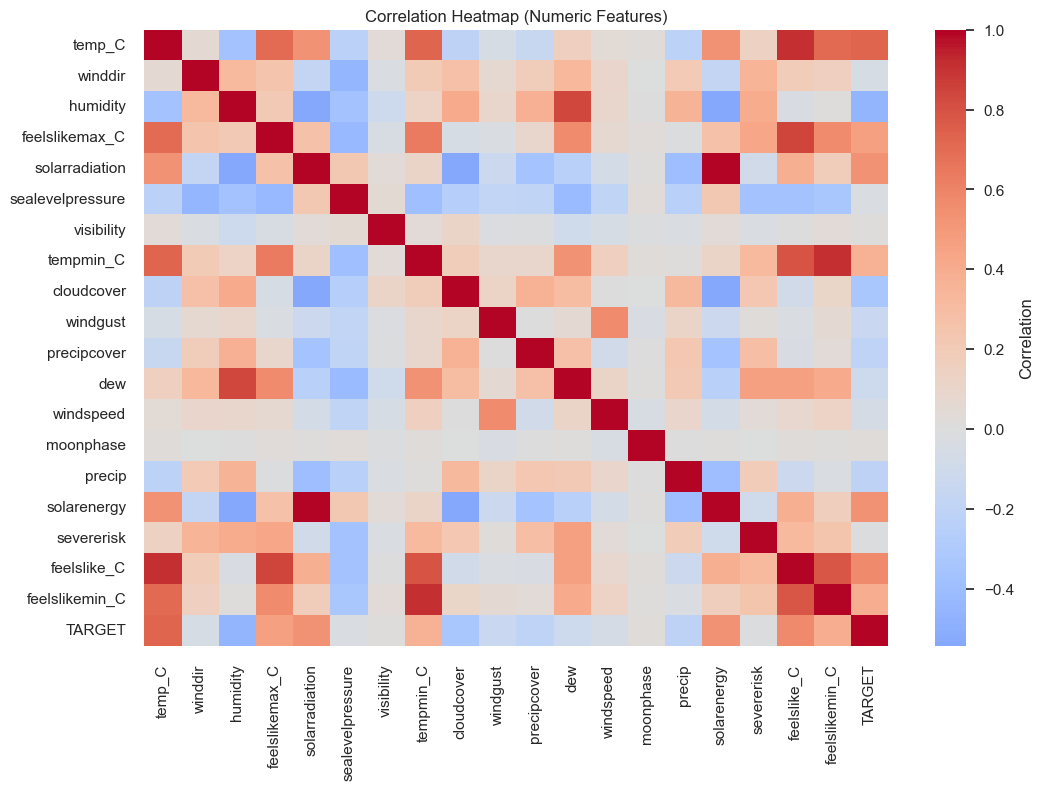

,TARGET
TARGET,1.000000
temp_C,0.725335
feelslike_C,0.577180
solarradiation,0.532252
solarenergy,0.531308
feelslikemax_C,0.457537
feelslikemin_C,0.394908
tempmin_C,0.367503
moonphase,0.020743
visibility,0.014831


In [11]:
# choose numeric features
numeric_df = df_shap.select_dtypes(include=["number"])

# matrix correlation
corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr, cmap="coolwarm", center=0,
    annot=False, cbar_kws={'label': 'Correlation'}
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.savefig('../figures/1_Preprocessing/correlation_heatmap_numeric_features.png', bbox_inches='tight')
plt.show()

# features có tương quan  tempmax_C
display(pd.DataFrame(corr["TARGET"].sort_values(ascending=False)))

Examine the correlation structure among numeric features to identify redundant or highly correlated variables.

In [12]:
# Drop columns based on SHAP analysis and domain knowledge
print("DROP COLUMNS BASED ON SHAP ANALYSIS AND CORRELATION")

# Features with zero SHAP importance (definitely drop)
zero_importance_features = [
    "snow", "snowdepth"  # SHAP importance = 0.000
]

# Features with very low SHAP importance 
low_importance_features = [
    "precipprob",  
    "feelslikemin_C",  
    "uvindex" 
      
]

# Text/metadata features (not useful for ML)
text_metadata_features = [
    "stations", "icon", "description", "conditions"
]

# Redundant features (based on correlation and domain knowledge)
redundant_features = [
    "solarenergy",  # highly correlated with solarradiation
    "sunrise", "sunset",  # time features, can be derived from datetime
    "severerisk",     # missing values 65%
    "preciptype" # missing values 20%
]

# Combine all features to drop
drop_cols = zero_importance_features + text_metadata_features + redundant_features + low_importance_features

print(f"Features to drop:")
print(f"  Zero importance: {zero_importance_features}")
print(f"  Text/metadata: {text_metadata_features}")
print(f"  Redundant: {redundant_features}")
print(f"  Low importance: {low_importance_features}")

# Check which features actually exist in the data
print(f"\nActually dropping: {drop_cols}")

# Drop columns
df = df.drop(columns=drop_cols)

print(f"\nNumber of columns after drop: {len(df.columns)}")
print(f"Remaining columns: {df.columns.tolist()}")

DROP COLUMNS BASED ON SHAP ANALYSIS AND CORRELATION
Features to drop:
  Zero importance: ['snow', 'snowdepth']
  Text/metadata: ['stations', 'icon', 'description', 'conditions']
  Redundant: ['solarenergy', 'sunrise', 'sunset', 'severerisk', 'preciptype']
  Low importance: ['precipprob', 'feelslikemin_C', 'uvindex']

Actually dropping: ['snow', 'snowdepth', 'stations', 'icon', 'description', 'conditions', 'solarenergy', 'sunrise', 'sunset', 'severerisk', 'preciptype', 'precipprob', 'feelslikemin_C', 'uvindex']

Number of columns after drop: 19
Remaining columns: ['name', 'datetime', 'dew', 'humidity', 'precip', 'precipcover', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'moonphase', 'tempmax_C', 'tempmin_C', 'temp_C', 'feelslikemax_C', 'feelslike_C']


Based on SHAP analysis, correlation patterns, and domain knowledge, we systematically remove features that are:

- Zero or near-zero importance
- Highly redundant with other features
- Text metadata not useful for modeling
- Have excessive missing values

## 2.6. Handling Missing Values in Visibility

The visibility column has approximately 11% missing values. We analyze the patterns of missingness and develop an appropriate imputation strategy.

In [13]:
print("VISIBILITY MISSING VALUES ANALYSIS")


visibility_missing = df['visibility'].isnull()
print(f"Missing values in visibility: {visibility_missing.sum()} ({visibility_missing.mean()*100:.2f}%)")

# Analyze visibility distribution and patterns
print(f"\nVisibility Statistics:")
print(f"  Mean: {df['visibility'].mean():.2f}")
print(f"  Median: {df['visibility'].median():.2f}")
print(f"  Std: {df['visibility'].std():.2f}")
print(f"  Min: {df['visibility'].min():.2f}")
print(f"  Max: {df['visibility'].max():.2f}")

# Check if missing values are random or have patterns
print(f"\nMissing values by province:")
missing_by_province = df.groupby('name')['visibility'].apply(lambda x: x.isnull().sum())
display(pd.DataFrame(missing_by_province.sort_values(ascending=False)))

print(f"\nMissing values by month:")
month = df['datetime'].dt.month
missing_by_month = df.groupby(month)['visibility'].apply(lambda x: x.isnull().sum())
display(pd.DataFrame(missing_by_month.sort_values(ascending=False)))

# Check correlation with other weather features
print(f"\nCorrelation with other features:")
correlations = df[['visibility', 'humidity', 'cloudcover', 'precip', 'solarradiation', 'tempmax_C']].corr()['visibility'].sort_values(ascending=False)
print(correlations)

VISIBILITY MISSING VALUES ANALYSIS
Missing values in visibility: 7909 (11.28%)

Visibility Statistics:
  Mean: 7.70
  Median: 6.40
  Std: 8.04
  Min: 3.10
  Max: 1025.60

Missing values by province:


,visibility
name,
Bình Phước,2566
Đồng Nai,2566
Tây Ninh,2566
Vĩnh Long,65
Trà Vinh,65
Sóc Trăng,65
Bạc Liêu,8
Cà Mau,8
An Giang,0



Missing values by month:


,visibility
datetime,
7,693
8,687
1,680
4,680
9,663
6,660
10,658
12,655
3,653



Correlation with other features:
visibility        1.000000
cloudcover        0.119821
solarradiation    0.040585
tempmax_C         0.018930
precip           -0.028916
humidity         -0.109633
Name: visibility, dtype: float64


Analyze the distribution and patterns of missing visibility values. We check if missingness is random or follows specific patterns by province or time.

In [15]:
def impute_visibility(df, *,
                      group_col='name',
                      time_col='datetime',
                      value_col='visibility',
                      use_log=True,
                      ffill_limit=3,           # giới hạn kéo đi bao nhiêu bước
                      allow_bfill=False):      # tránh dùng dữ liệu tương lai

    out = df.copy()
    out = out.sort_values([group_col, time_col])

    # Flag thiếu
    miss_flag = out[value_col].isna().astype(int)
    out[f'{value_col}_missing'] = miss_flag

    s = out[value_col].astype(float)

    # (Tùy chọn) log1p để giảm skew trước khi nội suy
    if use_log:
        s_log = s.apply(lambda v: np.log1p(v) if pd.notna(v) else v)

        # Nội suy chỉ "inside" trong từng tỉnh
        s_log = (out.groupby(group_col)[value_col]
                 .apply(lambda x: np.log1p(x).interpolate(method='linear',
                                                          limit_area='inside'))
                 .reset_index(level=0, drop=True))

        # Trả lại thang gốc
        s_interp = s_log.apply(lambda v: np.expm1(v) if pd.notna(v) else v)
    else:
        s_interp = (out.groupby(group_col)[value_col]
                    .apply(lambda x: x.interpolate(method='linear',
                                                   limit_area='inside'))
                    .reset_index(level=0, drop=True))

    out[value_col] = s_interp

    # Fallback 1: ffill có giới hạn
    out[value_col] = (out.groupby(group_col)[value_col]
                        .ffill(limit=ffill_limit)
                        .reset_index(level=0, drop=True))

    # Fallback 2: median theo tỉnh
    med_by_grp = out.groupby(group_col)[value_col].transform('median')
    out[value_col] = out[value_col].fillna(med_by_grp)

    # Fallback 3: nếu cả tỉnh hoàn toàn thiếu, dùng median toàn cục
    global_med = out[value_col].median()
    out[value_col] = out[value_col].fillna(global_med)

    return out

Define a sophisticated imputation function that uses multiple fallback strategies:

1. Linear interpolation (with optional log transformation to handle skewness)
2. Forward-fill with a limit to avoid propagating stale values
3. Province-level median for province-specific patterns
4. Global median as a final fallback

In [16]:
print(f"Missing values before imputation: {df['visibility'].isnull().sum()}")
df = impute_visibility(df)
print(f'Missing values after imputation: {df["visibility"].isnull().sum()}')

Missing values before imputation: 7909
Missing values after imputation: 0


Apply the imputation function and verify that all missing values have been filled.


Final visibility statistics:
  Mean: 8.48
  Median: 6.60
  Std: 7.89
  Min: 3.10
  Max: 1025.60
  Missing values: 0


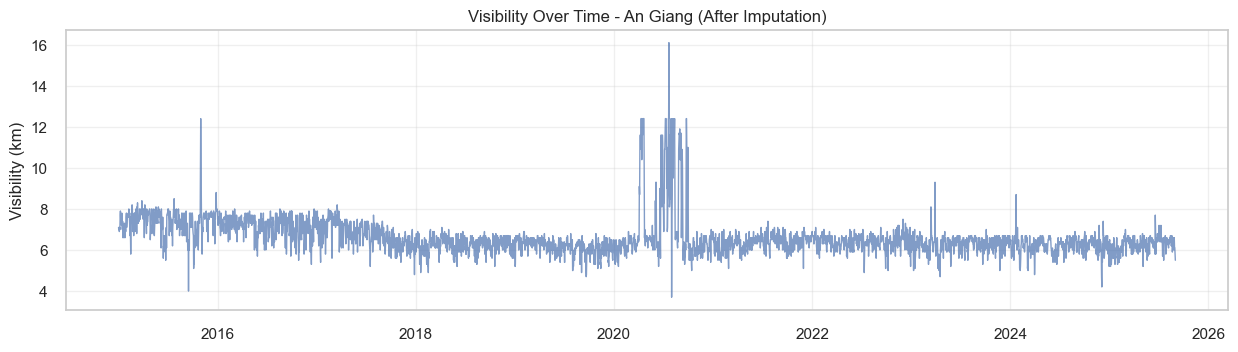

In [24]:
# Verify the imputation
print(f"\nFinal visibility statistics:")
print(f"  Mean: {df['visibility'].mean():.2f}")
print(f"  Median: {df['visibility'].median():.2f}")
print(f"  Std: {df['visibility'].std():.2f}")
print(f"  Min: {df['visibility'].min():.2f}")
print(f"  Max: {df['visibility'].max():.2f}")
print(f"  Missing values: {df['visibility'].isnull().sum()}")

# Visualize the imputed data
plt.figure(figsize=(15, 8))

# Plot visibility over time for a sample province
sample_province = df['name'].value_counts().index[0]
sample_data = df[df['name'] == sample_province].copy()
sample_data = sample_data.set_index('datetime').sort_index()

plt.subplot(2, 1, 1)
plt.plot(sample_data.index, sample_data['visibility'], alpha=0.7, linewidth=1)
plt.title(f'Visibility Over Time - {sample_province} (After Imputation)')
plt.ylabel('Visibility (km)')
plt.grid(True, alpha=0.3)

# # Plot distribution
# plt.subplot(2, 1, 2)
# plt.hist(df['visibility'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
# plt.title('Distribution of Visibility (After Imputation)')
# plt.xlabel('Visibility (km)')
# plt.ylabel('Frequency')
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()


Validate the imputation results by checking statistical properties and visualizing the time series for a sample province.

## 2.7. Outlier Detection and Analysis

Identify potential outliers using statistical methods (IQR and Z-score) to understand data quality and extreme values.

OUTLIER DETECTION AND ANALYSIS

Outlier Summary Table:


,Column,IQR Outliers,Z-Score Outliers,IQR Range
0,dew,3277,1079,"[66.70, 83.50]"
1,humidity,2105,1074,"[57.15, 103.95]"
2,precip,6597,1398,"[-0.40, 0.67]"
3,precipcover,4728,1679,"[-27.07, 56.24]"
4,windgust,1104,391,"[3.95, 36.35]"
5,windspeed,833,411,"[1.05, 19.85]"
6,winddir,0,0,"[-119.80, 457.80]"
7,sealevelpressure,452,158,"[1004.00, 1015.20]"
8,cloudcover,252,198,"[5.25, 119.25]"
9,visibility,6,6,"[-2.85, 20.75]"


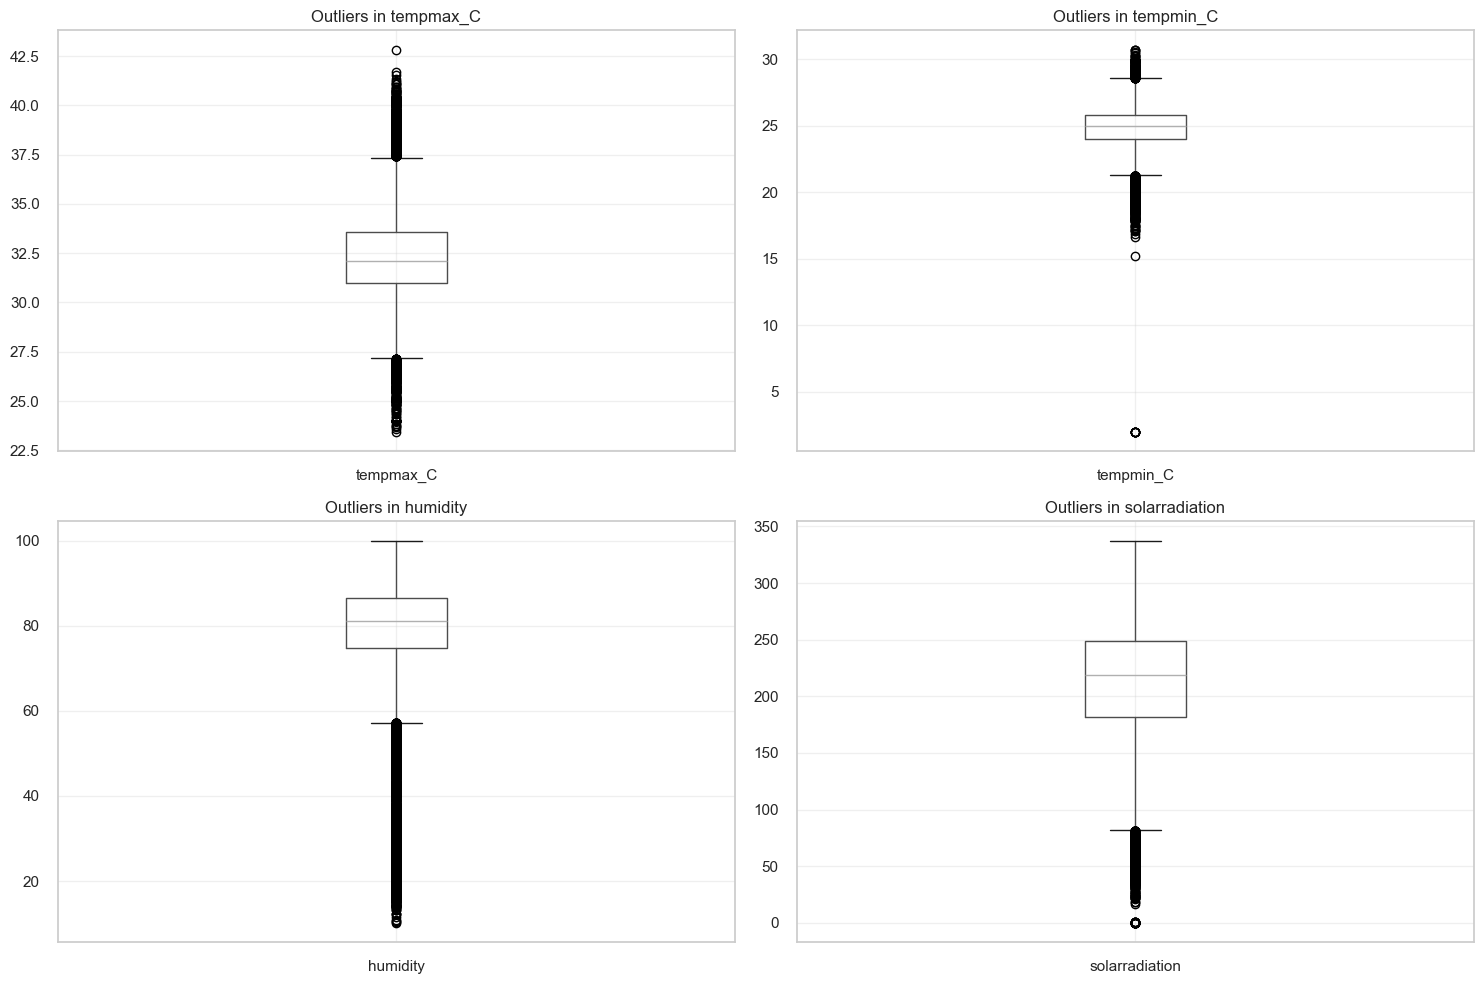

In [25]:
print("OUTLIER DETECTION AND ANALYSIS")

def detect_outliers_iqr(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

def detect_outliers_zscore(df, column, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())
    outliers = df[z_scores > threshold]
    return outliers

# Analyze outliers for key numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = []

for col in numeric_cols:
    if col in ['name', 'datetime']:  # Skip non-numeric columns
        continue
        
    # IQR method
    outliers_iqr, lower, upper = detect_outliers_iqr(df, col)
    n_outliers_iqr = len(outliers_iqr)
    
    # Z-score method
    outliers_zscore = detect_outliers_zscore(df, col)
    n_outliers_zscore = len(outliers_zscore)
    
    outlier_summary.append({
        'Column': col,
        'IQR Outliers': n_outliers_iqr,
        'Z-Score Outliers': n_outliers_zscore,
        'IQR Range': f"[{lower:.2f}, {upper:.2f}]"
    })
    
outlier_df = pd.DataFrame(outlier_summary)
print(f"\nOutlier Summary Table:")
display(outlier_df)

# Visualize outliers for key temperature columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

key_cols = ['tempmax_C', 'tempmin_C', 'humidity', 'solarradiation']

for i, col in enumerate(key_cols):
    if col in df.columns:
        # Box plot to show outliers
        df.boxplot(column=col, ax=axes[i])
        axes[i].set_title(f'Outliers in {col}')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('../figures/1_Preprocessing/outlier_analysis.png', bbox_inches='tight')
plt.show()


We use two complementary methods for outlier detection:

- IQR Method: Identifies values beyond 1.5 times the interquartile range
- Z-Score Method: Flags values more than 3 standard deviations from the mean

Note: In weather data, outliers may represent genuine extreme weather events rather than errors.

## 2.8. Data Quality Assessment

Evaluate overall data quality across multiple dimensions: completeness, uniqueness, and validity.

In [26]:
print("COMPREHENSIVE DATA QUALITY ASSESSMENT")
def data_quality_report(df):
    quality_metrics = {}
    
    for col in df.columns:
        # Completeness (non-null percentage)
        completeness = (1 - df[col].isnull().sum() / len(df)) * 100
        
        # Uniqueness (unique values percentage)
        uniqueness = df[col].nunique() / len(df) * 100
        
        # Validity (for numeric columns, check for reasonable ranges)
        validity = 100  # Default
        if col in ['tempmax_C', 'tempmin_C']:
            # Temperature should be between 0°C and 50°C
            valid_temp = ((df[col] >= 0) & (df[col] <= 50)).sum()
            validity = (valid_temp / len(df)) * 100
        elif col == 'humidity':
            # Humidity should be between 0% and 100%
            valid_humidity = ((df[col] >= 0) & (df[col] <= 100)).sum()
            validity = (valid_humidity / len(df)) * 100
        elif col == 'precip':
            # Precipitation should be non-negative
            valid_precip = (df[col] >= 0).sum()
            validity = (valid_precip / len(df)) * 100
        
        quality_metrics[col] = {
            'Completeness (%)': round(completeness, 2),
            'Uniqueness (%)': round(uniqueness, 2),
            'Validity (%)': round(validity, 2)
        }
    
    return pd.DataFrame(quality_metrics).T

# Generate quality report
quality_report = data_quality_report(df)
print("Data Quality Metrics:")
display(quality_report)

# Overall quality score
overall_completeness = quality_report['Completeness (%)'].mean()
overall_uniqueness = quality_report['Uniqueness (%)'].mean()
overall_validity = quality_report['Validity (%)'].mean()

print(f"\nOverall Data Quality Scores:")
print(f"  Completeness: {overall_completeness:.2f}%")
print(f"  Uniqueness: {overall_uniqueness:.2f}%")
print(f"  Validity: {overall_validity:.2f}%")



COMPREHENSIVE DATA QUALITY ASSESSMENT
Data Quality Metrics:


,Completeness (%),Uniqueness (%),Validity (%)
name,100.0,0.03,100.0
datetime,100.0,5.56,100.0
dew,100.0,0.76,100.0
humidity,100.0,1.22,100.0
precip,100.0,2.48,100.0
precipcover,100.0,0.04,100.0
windgust,100.0,0.25,100.0
windspeed,100.0,0.39,100.0
winddir,100.0,5.13,100.0
sealevelpressure,100.0,0.23,100.0



Overall Data Quality Scores:
  Completeness: 100.00%
  Uniqueness: 1.20%
  Validity: 100.00%


Generate a comprehensive quality report assessing:

- Completeness: Percentage of non-null values
- Uniqueness: Diversity of values (high for continuous variables, low for categorical)
- Validity: Whether values fall within reasonable/expected ranges

Data Consistency Checks:
Temperature consistency (max >= min): True
Non-negative precipitation: True
Humidity in valid range (0-100%): True
Non-negative solar radiation: True
Wind direction in valid range (0-360°): True


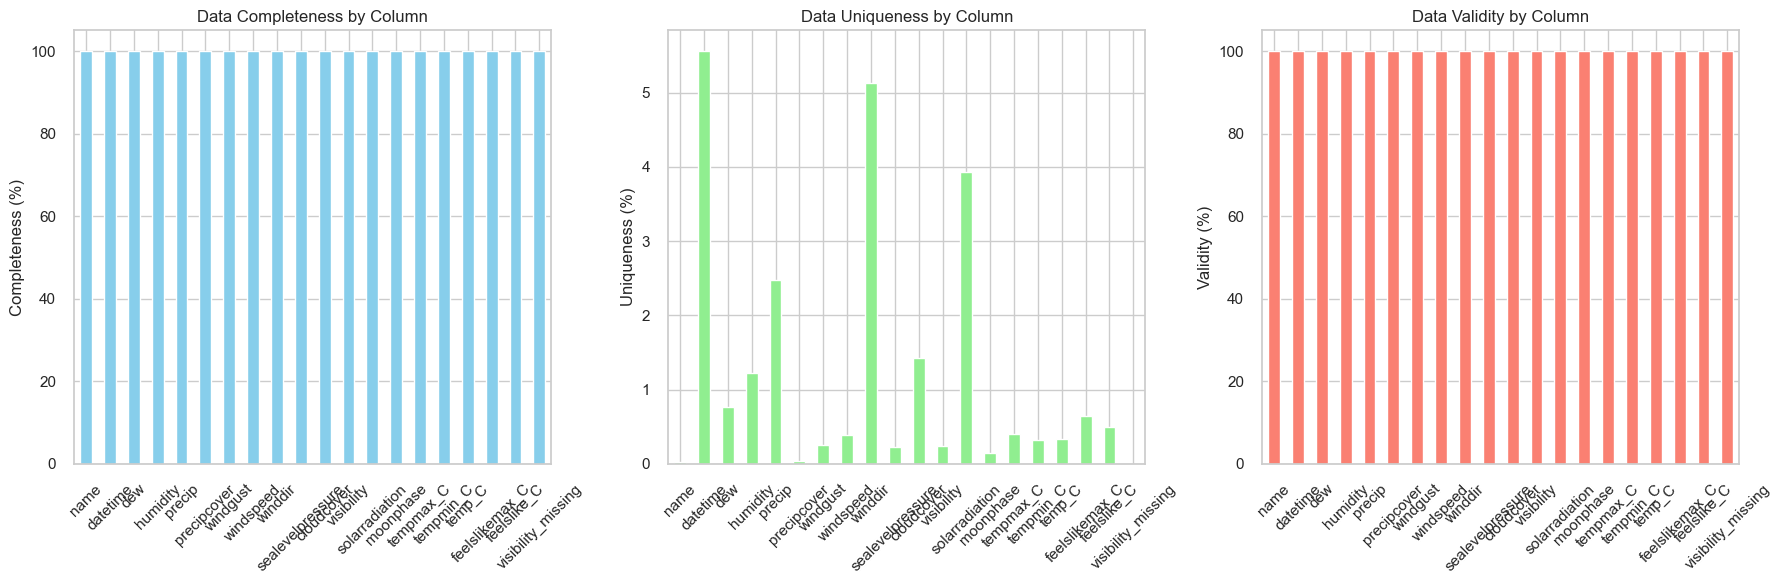

In [27]:
print(f"Data Consistency Checks:")

# Check 1: Max temp >= Min temp
temp_consistency = (df['tempmax_C'] >= df['tempmin_C']).all()
print(f"Temperature consistency (max >= min): {temp_consistency}")

# Check 2: No negative precipitation
precip_consistency = (df['precip'] >= 0).all()
print(f"Non-negative precipitation: {precip_consistency}")

# Check 3: Humidity in valid range
humidity_consistency = ((df['humidity'] >= 0) & (df['humidity'] <= 100)).all()
print(f"Humidity in valid range (0-100%): {humidity_consistency}")

# Check 4: Solar radiation non-negative
solar_consistency = (df['solarradiation'] >= 0).all()
print(f"Non-negative solar radiation: {solar_consistency}")

# Check 5: Wind direction in valid range (0-360)
wind_consistency = ((df['winddir'] >= 0) & (df['winddir'] <= 360)).all()
print(f"Wind direction in valid range (0-360°): {wind_consistency}")

# Visualize quality metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Completeness
quality_report['Completeness (%)'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Data Completeness by Column')
axes[0].set_ylabel('Completeness (%)')
axes[0].tick_params(axis='x', rotation=45)

# Uniqueness
quality_report['Uniqueness (%)'].plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Data Uniqueness by Column')
axes[1].set_ylabel('Uniqueness (%)')
axes[1].tick_params(axis='x', rotation=45)

# Validity
quality_report['Validity (%)'].plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Data Validity by Column')
axes[2].set_ylabel('Validity (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
# plt.savefig('../figures/1_Preprocessing/data_quality_metrics.png', bbox_inches='tight')
plt.show()


Perform logical consistency checks to ensure data relationships make sense (e.g., max temperature should be greater than or equal to min temperature).

In [28]:
print('data Shape after Cleaning:', df.shape)
print(f'Columns: {df.columns}')


data Shape after Cleaning: (70146, 20)
Columns: Index(['name', 'datetime', 'dew', 'humidity', 'precip', 'precipcover',
       'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover',
       'visibility', 'solarradiation', 'moonphase', 'tempmax_C', 'tempmin_C',
       'temp_C', 'feelslikemax_C', 'feelslike_C', 'visibility_missing'],
      dtype='object')


Summary of the cleaned dataset showing the final shape and retained columns.

# 3. Exploratory Data Analysis

Now that the data is cleaned, we conduct comprehensive exploratory analysis to understand weather patterns, trends, and relationships in Southern Vietnam.

In [29]:
# Check data types and unique values
print("DATA TYPES AND UNIQUE VALUES\n")
for col in df.columns:
    print(f"{col}: {df[col].dtype}, Unique values: {df[col].nunique()}")

DATA TYPES AND UNIQUE VALUES

name: object, Unique values: 18
datetime: datetime64[ns], Unique values: 3897
dew: float64, Unique values: 533
humidity: float64, Unique values: 854
precip: float64, Unique values: 1739
precipcover: float64, Unique values: 25
windgust: float64, Unique values: 178
windspeed: float64, Unique values: 271
winddir: float64, Unique values: 3595
sealevelpressure: float64, Unique values: 158
cloudcover: float64, Unique values: 994
visibility: float64, Unique values: 165
solarradiation: float64, Unique values: 2755
moonphase: float64, Unique values: 96
tempmax_C: float64, Unique values: 284
tempmin_C: float64, Unique values: 226
temp_C: float64, Unique values: 233
feelslikemax_C: float64, Unique values: 450
feelslike_C: float64, Unique values: 352
visibility_missing: int64, Unique values: 2


Examine data types and cardinality of each variable to understand their nature and distribution.

In [30]:
print(f"Rows: {len(df)}")
print(f"Columns: {df.shape[1]}")
print(f"Provinces: {df['name'].nunique()}")
print(f"Date range: {df['datetime'].min().date()} -> {df['datetime'].max().date()}")

Rows: 70146
Columns: 20
Provinces: 18
Date range: 2015-01-01 -> 2025-09-01


Summary of dataset dimensions and temporal coverage.

In [31]:
print("BASIC STATISTICS")
df.describe().T

BASIC STATISTICS


,count,mean,min,25%,50%,75%,max,std
datetime,70146,2020-05-02 00:00:00.000000256,2015-01-01 00:00:00,2017-09-01 00:00:00,2020-05-02 00:00:00,2023-01-01 00:00:00,2025-09-01 00:00:00,NaN
dew,70146.0,74.400572,21.3,73.0,75.8,77.2,82.1,5.105432
humidity,70146.0,79.435576,10.2,74.7,81.1,86.4,100.0,10.7354
precip,70146.0,0.231279,0.0,0.004,0.043,0.272,9.047,0.47077
precipcover,70146.0,16.226831,0.0,4.17,8.33,25.0,100.0,20.743031
windgust,70146.0,20.636994,5.1,16.1,19.7,24.2,134.2,6.307139
windspeed,70146.0,10.545692,2.2,8.1,10.3,12.8,108.3,3.724737
winddir,70146.0,171.269884,0.0,96.8,180.6,241.2,360.0,84.988818
sealevelpressure,70146.0,1009.599842,994.8,1008.2,1009.5,1011.0,1017.1,2.072952
cloudcover,70146.0,62.092575,0.0,48.0,60.2,76.5,100.0,19.631561


Calculate descriptive statistics for all numeric variables to understand central tendencies, spread, and ranges.

## 3.1. Distribution Analysis

Visualize the distributions of key meteorological variables to understand their characteristics and identify potential skewness or multimodality.

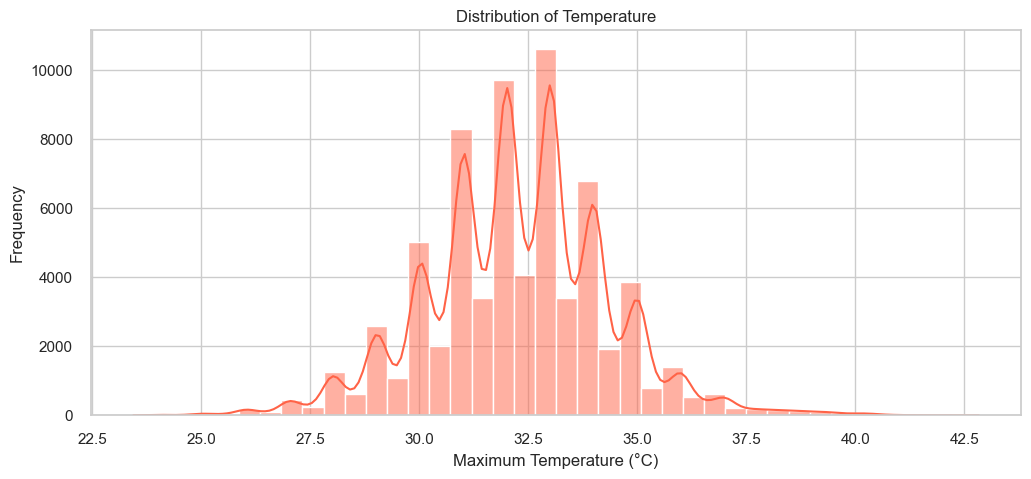

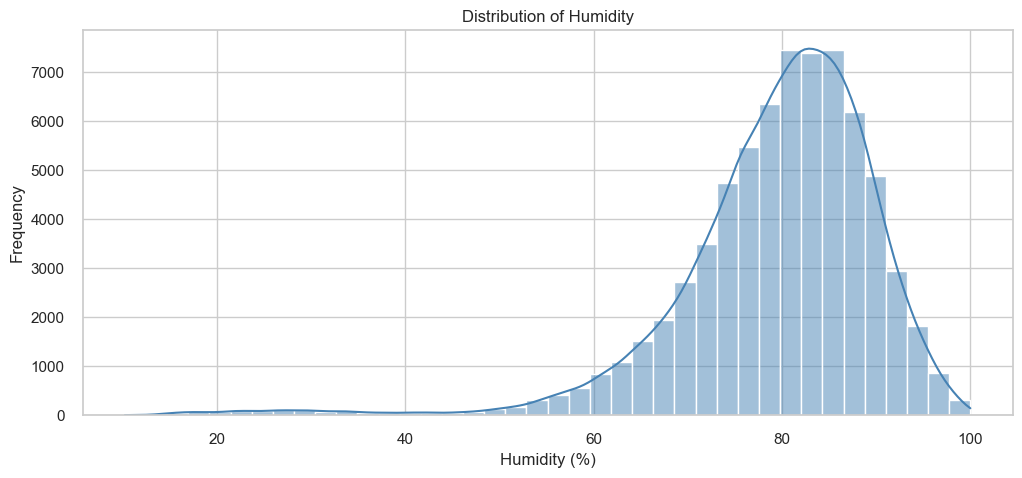

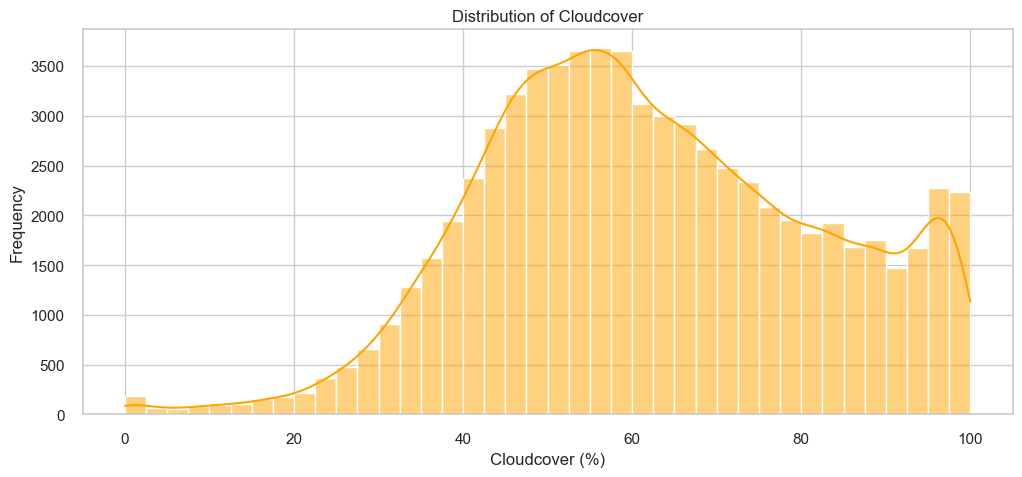

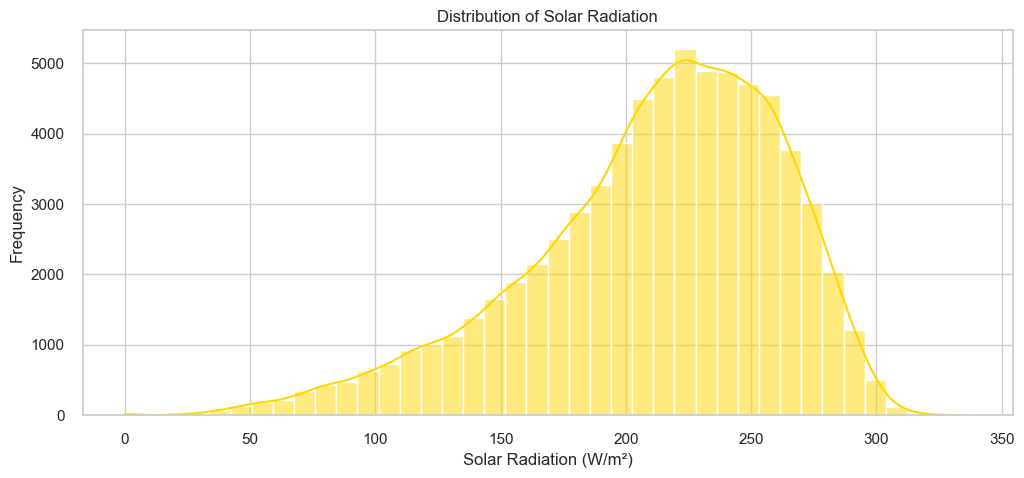

In [32]:
# Temperature distribution
plt.figure(figsize=(12,5))
sns.histplot(df['tempmax_C'], bins=40, kde=True, color='tomato')
plt.title('Distribution of Temperature')
plt.xlabel('Maximum Temperature (°C)')
plt.ylabel('Frequency')
plt.savefig('../figures/1_Preprocessing/temperature_distribution.png', bbox_inches='tight')
plt.show()

# Humidity distribution
plt.figure(figsize=(12,5))
sns.histplot(df['humidity'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.savefig('../figures/1_Preprocessing/humidity_distribution.png', bbox_inches='tight')
plt.show()

# Cloudcover distribution
plt.figure(figsize=(12,5))
sns.histplot(df['cloudcover'], bins=40, kde=True, color='orange')
plt.title('Distribution of Cloudcover')
plt.xlabel('Cloudcover (%)')
plt.ylabel('Frequency')
plt.savefig('../figures/1_Preprocessing/cloudcover_distribution.png', bbox_inches='tight')
plt.show()

# Solarradiation distribution
plt.figure(figsize=(12,5))
sns.histplot(df['solarradiation'], bins=40, kde=True, color='gold')
plt.title('Distribution of Solar Radiation')
plt.xlabel('Solar Radiation (W/m²)')
plt.ylabel('Frequency')
plt.savefig('../figures/1_Preprocessing/solarradiation_distribution.png', bbox_inches='tight')
plt.show()

## 3.2. Geographic Analysis: Temperature by Province

Compare average maximum temperatures across the 18 provinces to identify the hottest and coolest regions.

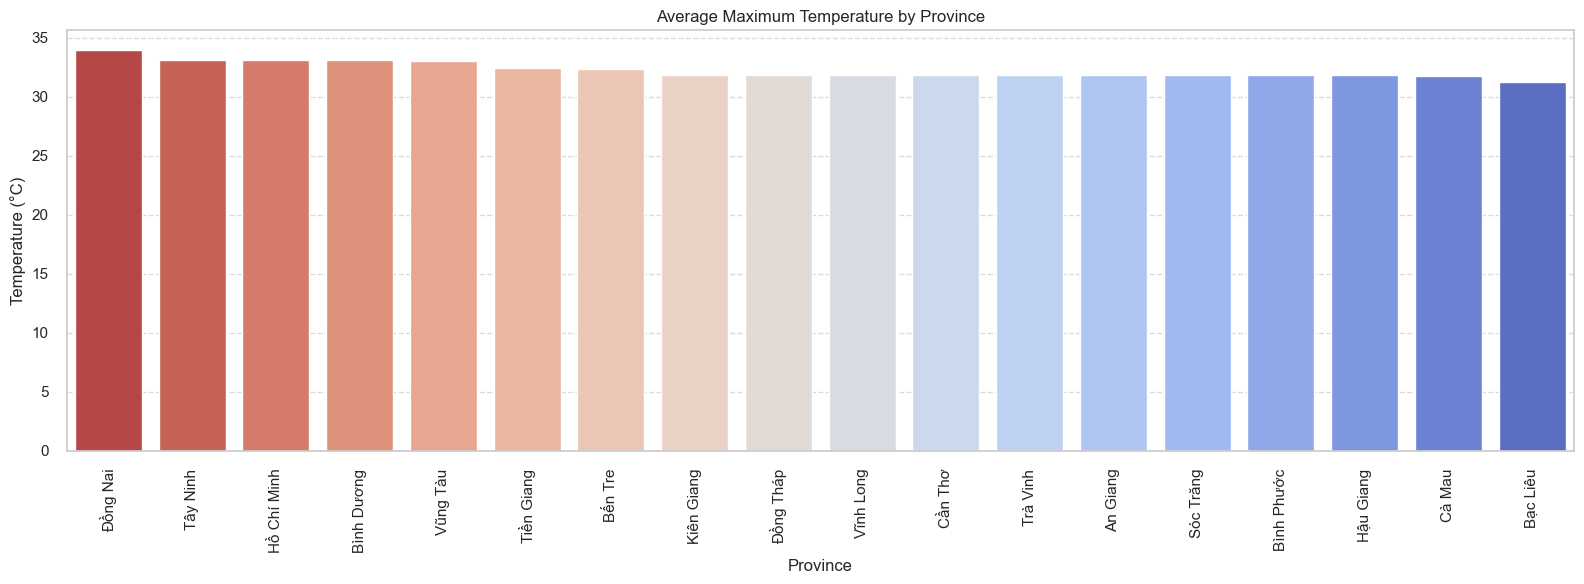

In [33]:
# Compute average temperature per province
avg_max_temp = df.groupby('name')['tempmax_C'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(16,6))
sns.barplot(x=avg_max_temp.index, y=avg_max_temp.values, palette="coolwarm_r")
plt.title('Average Maximum Temperature by Province')
plt.ylabel('Temperature (°C)')
plt.xlabel('Province')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../figures/1_Preprocessing/average_max_temp_by_province.png', bbox_inches='tight')
plt.show()

## 3.3. Seasonal Analysis: Temperature by Month

Examine how temperatures vary throughout the year across different provinces to understand seasonal patterns.

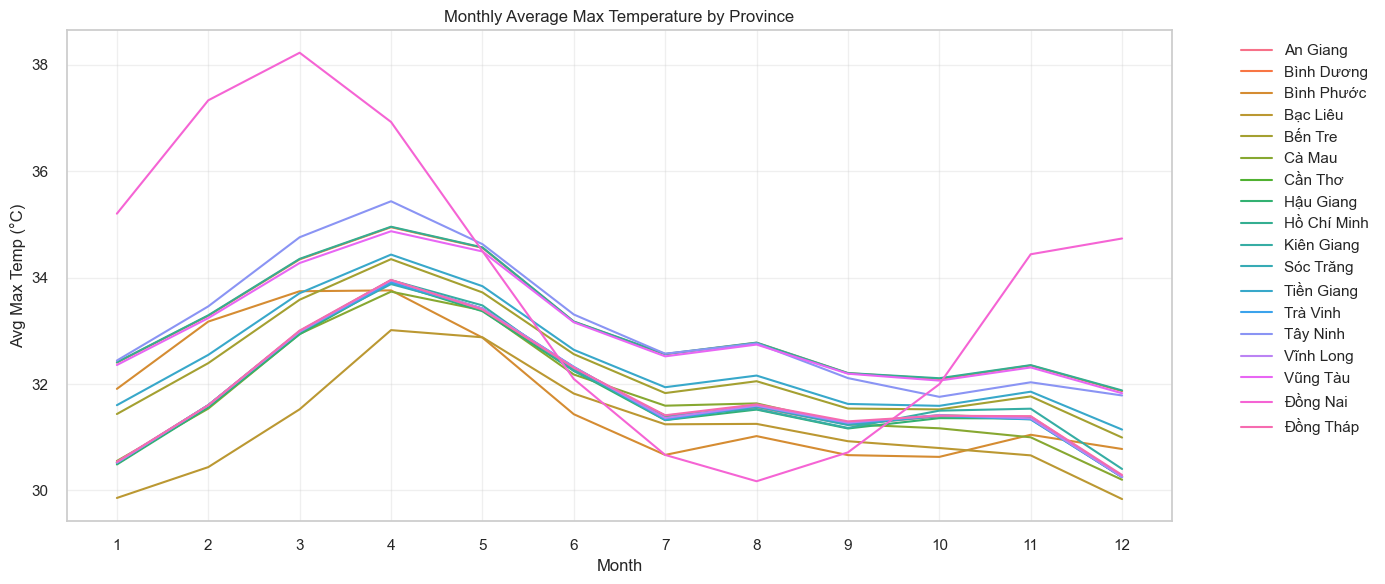

In [34]:
monthly_province_avg = (
    df.groupby([df['name'], df['datetime'].dt.month])['tempmax_C']
      .mean().reset_index()
)

plt.figure(figsize=(14,6))
sns.lineplot(
    data=monthly_province_avg,
    x='datetime', y='tempmax_C', hue='name'
)
plt.title("Monthly Average Max Temperature by Province")
plt.xlabel("Month")
plt.ylabel("Avg Max Temp (°C)")
plt.grid(alpha=0.3)
plt.xticks(range(1,13))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/1_Preprocessing/monthly_average_max_temp_by_province.png', bbox_inches='tight')
plt.show()

Plot monthly average maximum temperature for all provinces to identify seasonal trends.

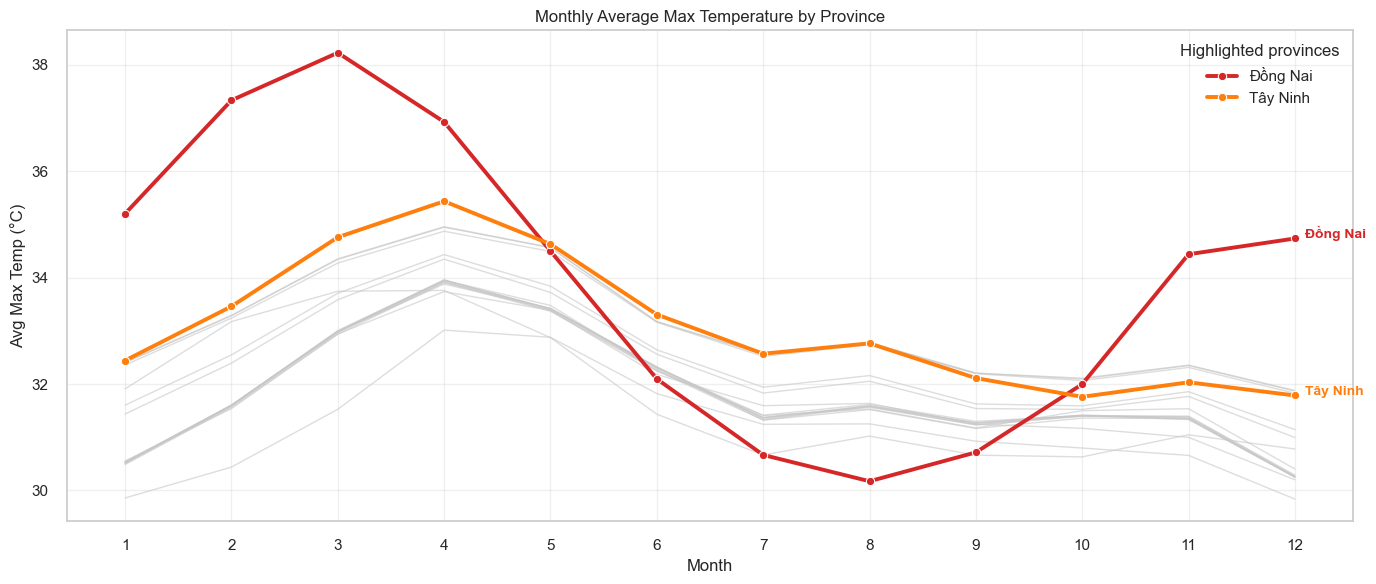

In [35]:
# Tính trung bình theo tỉnh để tìm 2 tỉnh nóng nhất
monthly_province_avg = (
    df.assign(month=df['datetime'].dt.month)
      .groupby(['name','month'])['tempmax_C']
      .mean().reset_index()
)

# Lấy 2 tỉnh nóng nhất
top2 = (monthly_province_avg.groupby('name')['tempmax_C']
        .mean().sort_values(ascending=False).head(2).index.tolist())

plt.figure(figsize=(14,6))

# Vẽ tất cả tỉnh khác bằng màu xám nhạt
sns.lineplot(
    data=monthly_province_avg[~monthly_province_avg['name'].isin(top2)],
    x='month', y='tempmax_C', hue='name',
    palette=['#C7C7C7'],     # xám nhạt
    linewidth=1, alpha=0.6, legend=False
)

# Vẽ 2 tỉnh nóng nhất với màu nổi (đỏ & cam)
highlight_colors = ['#d62728', '#ff7f0e']   # đỏ & cam

for i, prov in enumerate(top2):
    sub = monthly_province_avg[monthly_province_avg['name'] == prov]
    sns.lineplot(
        data=sub, x='month', y='tempmax_C',
        color=highlight_colors[i], linewidth=2.8, marker='o', label=prov, zorder=3
    )
    # Ghi nhãn tên tỉnh ở điểm cuối
    last = sub.sort_values('month').iloc[-1]
    plt.text(last['month']+0.1, last['tempmax_C'],
             prov, color=highlight_colors[i], fontsize=10, weight='bold')

plt.title("Monthly Average Max Temperature by Province")
plt.xlabel("Month"); plt.ylabel("Avg Max Temp (°C)")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.legend(title="Highlighted provinces", loc='upper right')
plt.tight_layout()
plt.savefig('../figures/1_Preprocessing/monthly_average_max_temp_by_province.png', bbox_inches='tight')
plt.show()

Highlight the two hottest provinces while showing all others in the background for context.

## 3.4. Temporal Heatmap: Year by Month

Create a heatmap showing how average maximum temperature varies across years and months to identify long-term trends and seasonal consistency.

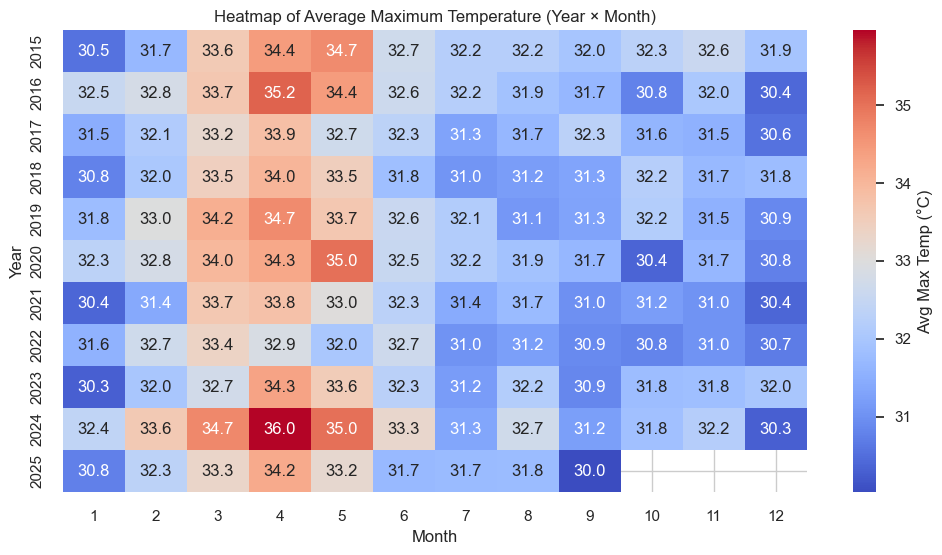

In [36]:
# Tạo bảng pivot: hàng = year, cột = month, giá trị = nhiệt độ TB
heatmap_data = (
    df.groupby([df['datetime'].dt.year, df['datetime'].dt.month])['tempmax_C']
      .mean()
      .unstack()
)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={'label': 'Avg Max Temp (°C)'}
)
plt.title("Heatmap of Average Maximum Temperature (Year × Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.savefig('../figures/1_Preprocessing/heatmap_average_max_temp_by_year_month.png', bbox_inches='tight')
plt.show()

## 3.5. Temperature Distribution by Province: Violin Plots

Violin plots combine box plots with kernel density estimation to show the full distribution shape of temperatures for each province.

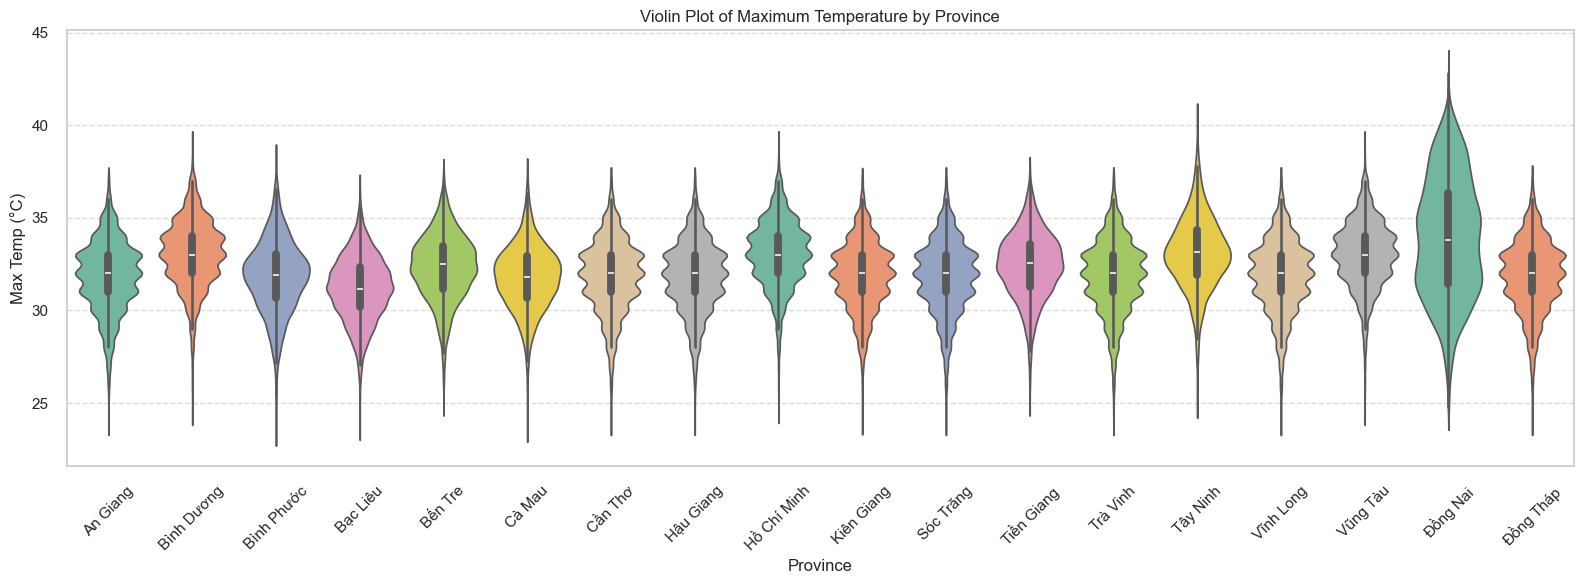

In [37]:
# Violin plot: phân phối dạng density
plt.figure(figsize=(16,6))
sns.violinplot(
    data=df,
    x="name", y="tempmax_C",
    palette="Set2", inner="box"   # inner="box" để thấy median + quartile
)
plt.xticks(rotation=45)
plt.title("Violin Plot of Maximum Temperature by Province")
plt.xlabel("Province")
plt.ylabel("Max Temp (°C)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig('../figures/1_Preprocessing/violin_plot_max_temp_by_province.png', bbox_inches='tight')
plt.show()

## 3.6. Relationship Analysis: Scatter Plots

Examine relationships between maximum temperature and key weather variables to understand potential drivers of temperature variation.

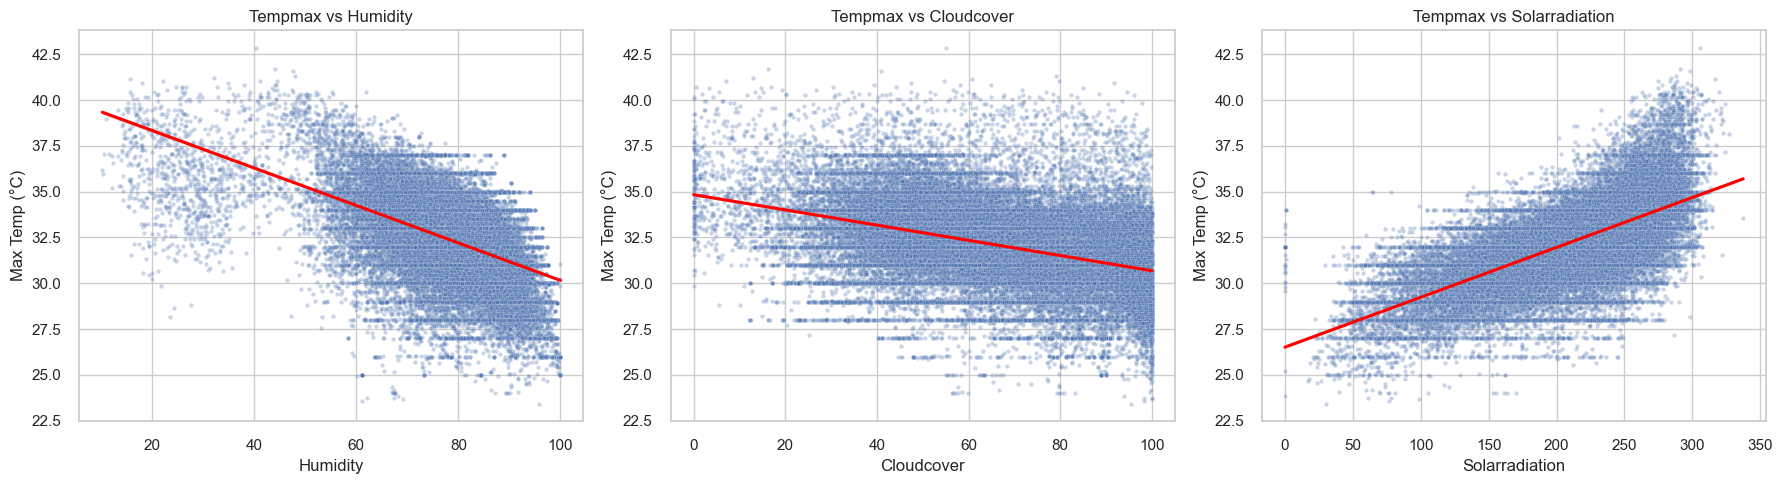

In [38]:
features = ["humidity", "cloudcover", "solarradiation"]

plt.figure(figsize=(18,5))

for i, col in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(data=df, x=col, y="tempmax_C", alpha=0.3, s=10)
    sns.regplot(data=df, x=col, y="tempmax_C", scatter=False, color="red")
    plt.title(f"Tempmax vs {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Max Temp (°C)")

plt.tight_layout()
plt.savefig('../figures/1_Preprocessing/scatter_plot_tempmax_vs_features.png', bbox_inches='tight')
plt.show()

## 3.7. Correlation Analysis

Compute and visualize the correlation matrix to identify linear relationships between all numeric weather variables.

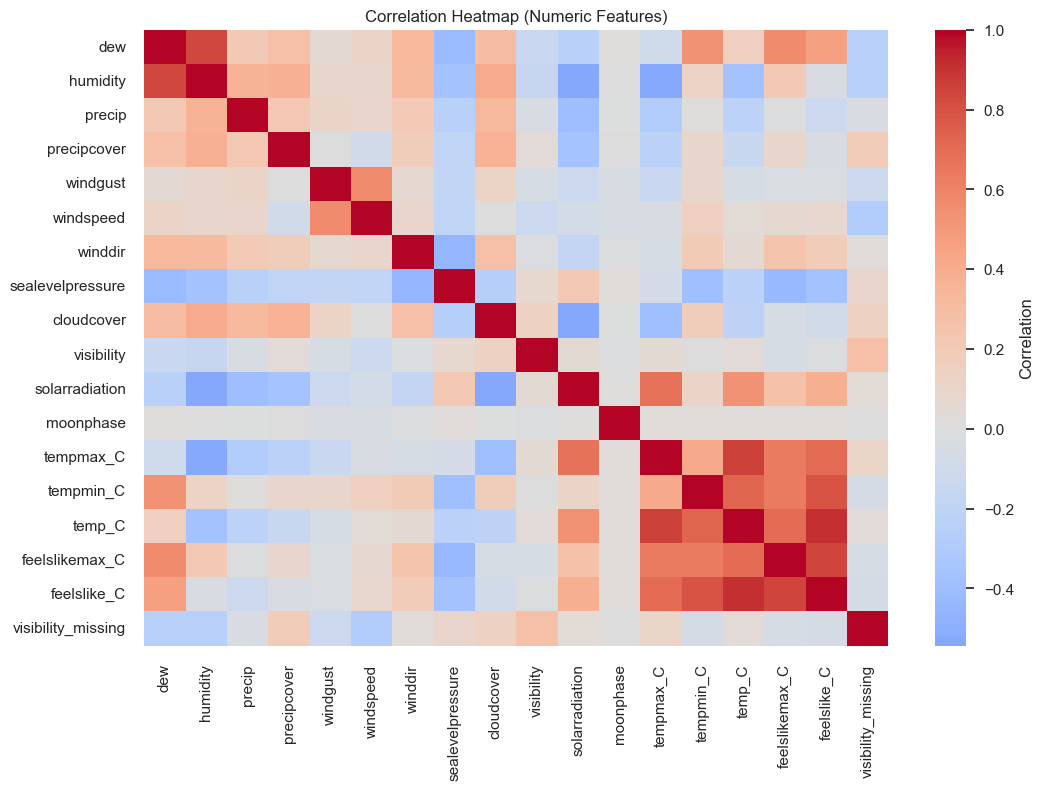

tempmax_C             1.000000
temp_C                0.866564
feelslike_C           0.703084
solarradiation        0.670579
feelslikemax_C        0.636256
tempmin_C             0.420538
visibility_missing    0.106966
visibility            0.048953
moonphase             0.022782
windspeed            -0.034251
winddir              -0.047334
sealevelpressure     -0.066443
dew                  -0.099214
windgust             -0.145332
precipcover          -0.226612
precip               -0.272266
cloudcover           -0.394009
humidity             -0.530779
Name: tempmax_C, dtype: float64


In [39]:
# choose numeric features
numeric_df = df.select_dtypes(include=["int64", "float64"])

# matrix correlation
corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr, cmap="coolwarm", center=0,
    annot=False, cbar_kws={'label': 'Correlation'}
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.savefig('../figures/1_Preprocessing/correlation_heatmap_numeric_features.png', bbox_inches='tight')
plt.show()

# top 10 feature có tương quan cao nhất với tempmax_C
print(corr["tempmax_C"].sort_values(ascending=False))

## 3.8. Time Series Analysis

Conduct in-depth time series analysis including trend detection, seasonal decomposition, and autocorrelation to understand temporal patterns.

TIME SERIES ANALYSIS
Temporal Features Added:
  Year range: 2015 - 2025
  Month range: 1 - 12
  Day of year range: 1 - 366


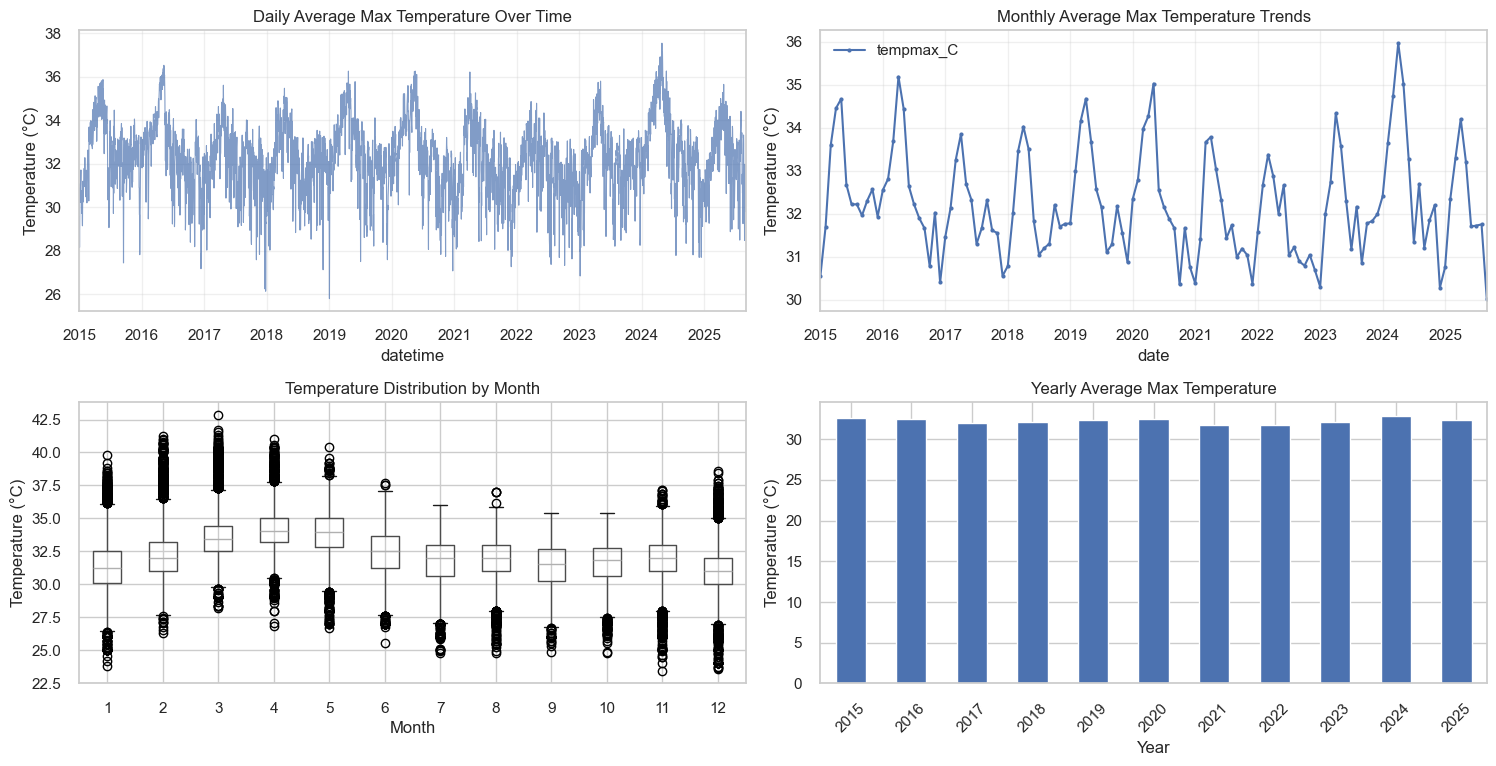


Seasonal Decomposition Analysis:


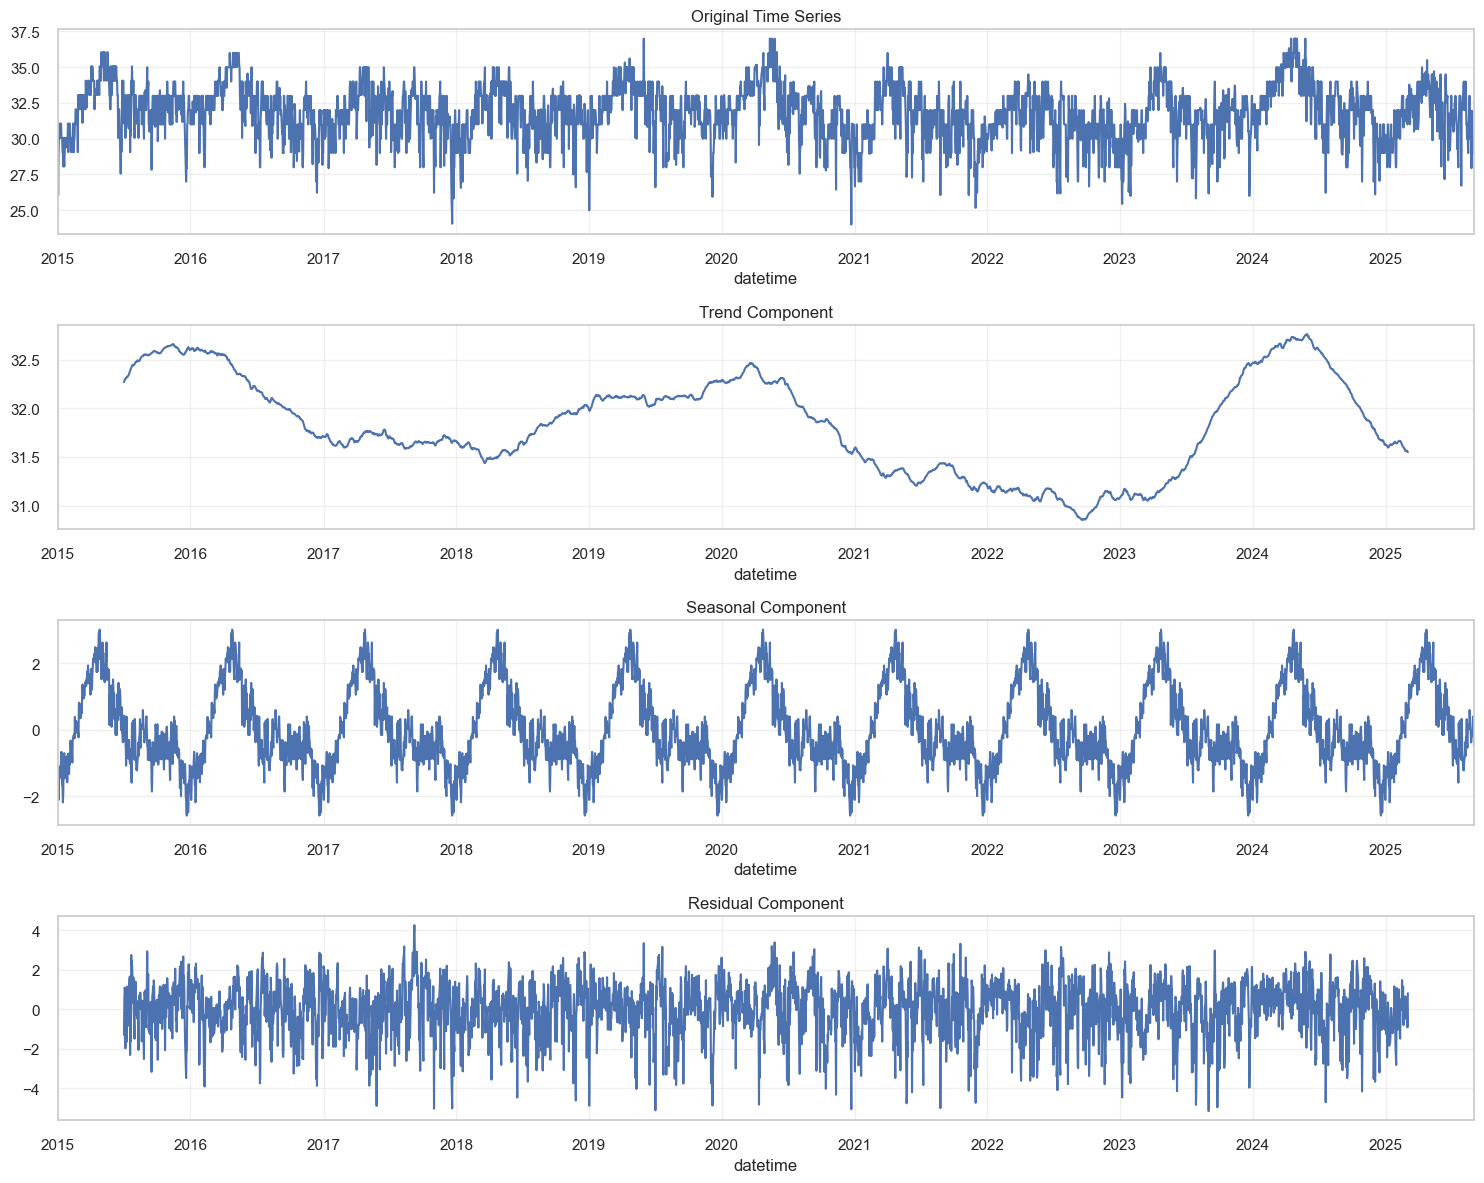

Seasonal decomposition completed for An Giang
  Trend: Decreasing
  Seasonal amplitude: 1.18°C
Autocorrelation Analysis:


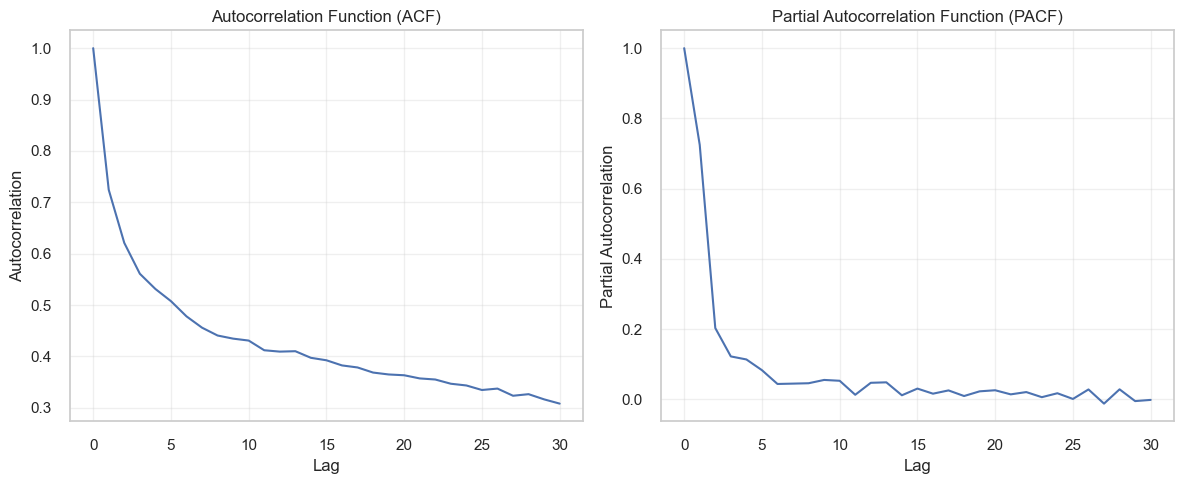

Significant autocorrelation lags: [0, 1, 2, 3, 4]
Temperature Statistics by Time Periods:
Yearly Statistics:


,mean,std,min,max
year,,,,
2015,32.57,1.91,24.83,40.67
2016,32.52,2.11,24.67,40.83
2017,32.05,1.97,23.56,41.06
2018,32.07,1.91,23.83,40.94
2019,32.41,2.01,23.44,39.83


Monthly Statistics:


,mean,std,min,max
month,,,,
1,31.35,2.00,23.83,39.78
2,32.41,1.99,26.33,41.22
3,33.63,1.79,28.17,42.83
4,34.33,1.67,26.83,41.06
5,33.71,1.86,26.67,40.44
6,32.44,1.67,25.56,37.67
7,31.62,1.72,24.78,36.00
8,31.77,1.61,24.78,37.00
9,31.41,1.67,24.83,35.44


Quarterly Statistics:


,mean,std,min,max
quarter,,,,
1,32.47,2.15,23.83,42.83
2,33.49,1.90,25.56,41.06
3,31.61,1.67,24.78,37.00
4,31.39,1.81,23.44,38.56


In [ ]:
print("TIME SERIES ANALYSIS")

# Add temporal features for analysis
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day_of_year'] = df['datetime'].dt.dayofyear
df['day_of_week'] = df['datetime'].dt.dayofweek
df['quarter'] = df['datetime'].dt.quarter

print("Temporal Features Added:")
print(f"  Year range: {df['year'].min()} - {df['year'].max()}")
print(f"  Month range: {df['month'].min()} - {df['month'].max()}")
print(f"  Day of year range: {df['day_of_year'].min()} - {df['day_of_year'].max()}")

# 1. Temperature trends over time
plt.figure(figsize=(15, 8))

# Daily average temperature over time
daily_avg = df.groupby('datetime')['tempmax_C'].mean()
plt.subplot(2, 2, 1)
daily_avg.plot(alpha=0.7, linewidth=0.8)
plt.title('Daily Average Max Temperature Over Time')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)

# Monthly average temperature trends
monthly_avg = df.groupby(['year', 'month'])['tempmax_C'].mean().reset_index()
monthly_avg['date'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))
plt.subplot(2, 2, 2)
monthly_avg.plot(x='date', y='tempmax_C', ax=plt.gca(), marker='o', markersize=3)
plt.title('Monthly Average Max Temperature Trends')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)

# Seasonal patterns (monthly box plot)
plt.subplot(2, 2, 3)
df.boxplot(column='tempmax_C', by='month', ax=plt.gca())
plt.title('Temperature Distribution by Month')
plt.ylabel('Temperature (°C)')
plt.xlabel('Month')
plt.suptitle('')  # Remove default title

# Yearly temperature trends
yearly_avg = df.groupby('year')['tempmax_C'].mean()
plt.subplot(2, 2, 4)
yearly_avg.plot(kind='bar', ax=plt.gca())
plt.title('Yearly Average Max Temperature')
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../figures/1_Preprocessing/time_series_analysis.png', bbox_inches='tight')
plt.show()

# 2. Seasonal decomposition (for one province as example)
print("\nSeasonal Decomposition Analysis:")
# Select a representative province for detailed analysis
sample_province = df['name'].value_counts().index[0]  # Most data points
sample_data = df[df['name'] == sample_province].copy()
sample_data = sample_data.set_index('datetime').sort_index()

# Resample to daily data
daily_data = sample_data['tempmax_C'].resample('D').mean().dropna()

if len(daily_data) > 365:  # Need at least 1 year of data
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    # Perform seasonal decomposition
    decomposition = seasonal_decompose(daily_data, model='additive', period=365)
    
    # Plot decomposition
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    
    decomposition.observed.plot(ax=axes[0], title='Original Time Series')
    decomposition.trend.plot(ax=axes[1], title='Trend Component')
    decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component')
    decomposition.resid.plot(ax=axes[3], title='Residual Component')
    
    for ax in axes:
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/1_Preprocessing/seasonal_decomposition.png', bbox_inches='tight')
    plt.show()
    
    print(f"Seasonal decomposition completed for {sample_province}")
    print(f"  Trend: {'Increasing' if decomposition.trend.dropna().iloc[-1] > decomposition.trend.dropna().iloc[0] else 'Decreasing'}")
    print(f"  Seasonal amplitude: {decomposition.seasonal.std():.2f}°C")
else:
    print(f"Insufficient data for seasonal decomposition in {sample_province}")

# 3. Temperature autocorrelation analysis
print("Autocorrelation Analysis:")
# Calculate autocorrelation for temperature
from statsmodels.tsa.stattools import acf, pacf

if len(daily_data) > 30:
    # Autocorrelation function
    autocorr = acf(daily_data.dropna(), nlags=30)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(autocorr)
    plt.title('Autocorrelation Function (ACF)')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.grid(True, alpha=0.3)
    
    # Partial autocorrelation function
    pacf_values = pacf(daily_data.dropna(), nlags=30)
    plt.subplot(1, 2, 2)
    plt.plot(pacf_values)
    plt.title('Partial Autocorrelation Function (PACF)')
    plt.xlabel('Lag')
    plt.ylabel('Partial Autocorrelation')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/1_Preprocessing/autocorrelation_analysis.png', bbox_inches='tight')
    plt.show()
    
    # Find significant lags
    significant_lags = np.where(np.abs(autocorr) > 0.2)[0]
    print(f"Significant autocorrelation lags: {significant_lags[:5].tolist()}")

# 4. Temperature statistics by time periods
print("Temperature Statistics by Time Periods:")
# By year
yearly_stats = df.groupby('year')['tempmax_C'].agg(['mean', 'std', 'min', 'max']).round(2)
print("Yearly Statistics:")
display(yearly_stats.head())

# By month
monthly_stats = df.groupby('month')['tempmax_C'].agg(['mean', 'std', 'min', 'max']).round(2)
print("Monthly Statistics:")
display(monthly_stats)

# By quarter
quarterly_stats = df.groupby('quarter')['tempmax_C'].agg(['mean', 'std', 'min', 'max']).round(2)
print("Quarterly Statistics:")
display(quarterly_stats)


Create temporal features and analyze temperature trends at multiple time scales:

- Daily variations and trends
- Monthly aggregations and patterns  
- Yearly averages and long-term trends
- Seasonal decomposition to separate trend, seasonal, and residual components
- Autocorrelation analysis to identify temporal dependencies

In [41]:
#Lưu data sau khi xử lý
df.to_csv('../data/processed/Southern_Vietnam_Weather_processed.csv', index = False, encoding='utf-8-sig')

# 4. Export Processed Data

Save the cleaned and processed dataset for use in subsequent modeling and analysis notebooks.